In [52]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("29-country_data.csv")


In [53]:
df.info()
df.head(25)
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.5 KB


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [54]:
df.sort_values(by = "gdpp", ascending = False)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
91,Luxembourg,2.8,175.00,7.77,142.0,91700,3.620,81.3,1.63,105000
114,Norway,3.2,39.70,9.48,28.5,62300,5.950,81.0,1.95,87800
145,Switzerland,4.5,64.00,11.50,53.3,55500,0.317,82.2,1.52,74600
123,Qatar,9.0,62.30,1.81,23.8,125000,6.980,79.5,2.07,70300
44,Denmark,4.1,50.50,11.40,43.6,44000,3.220,79.5,1.87,58000
...,...,...,...,...,...,...,...,...,...,...
132,Sierra Leone,160.0,16.80,13.10,34.5,1220,17.200,55.0,5.20,399
112,Niger,123.0,22.20,5.16,49.1,814,2.550,58.8,7.49,348
37,"Congo, Dem. Rep.",116.0,41.10,7.91,49.6,609,20.800,57.5,6.54,334
88,Liberia,89.3,19.10,11.80,92.6,700,5.470,60.8,5.02,327


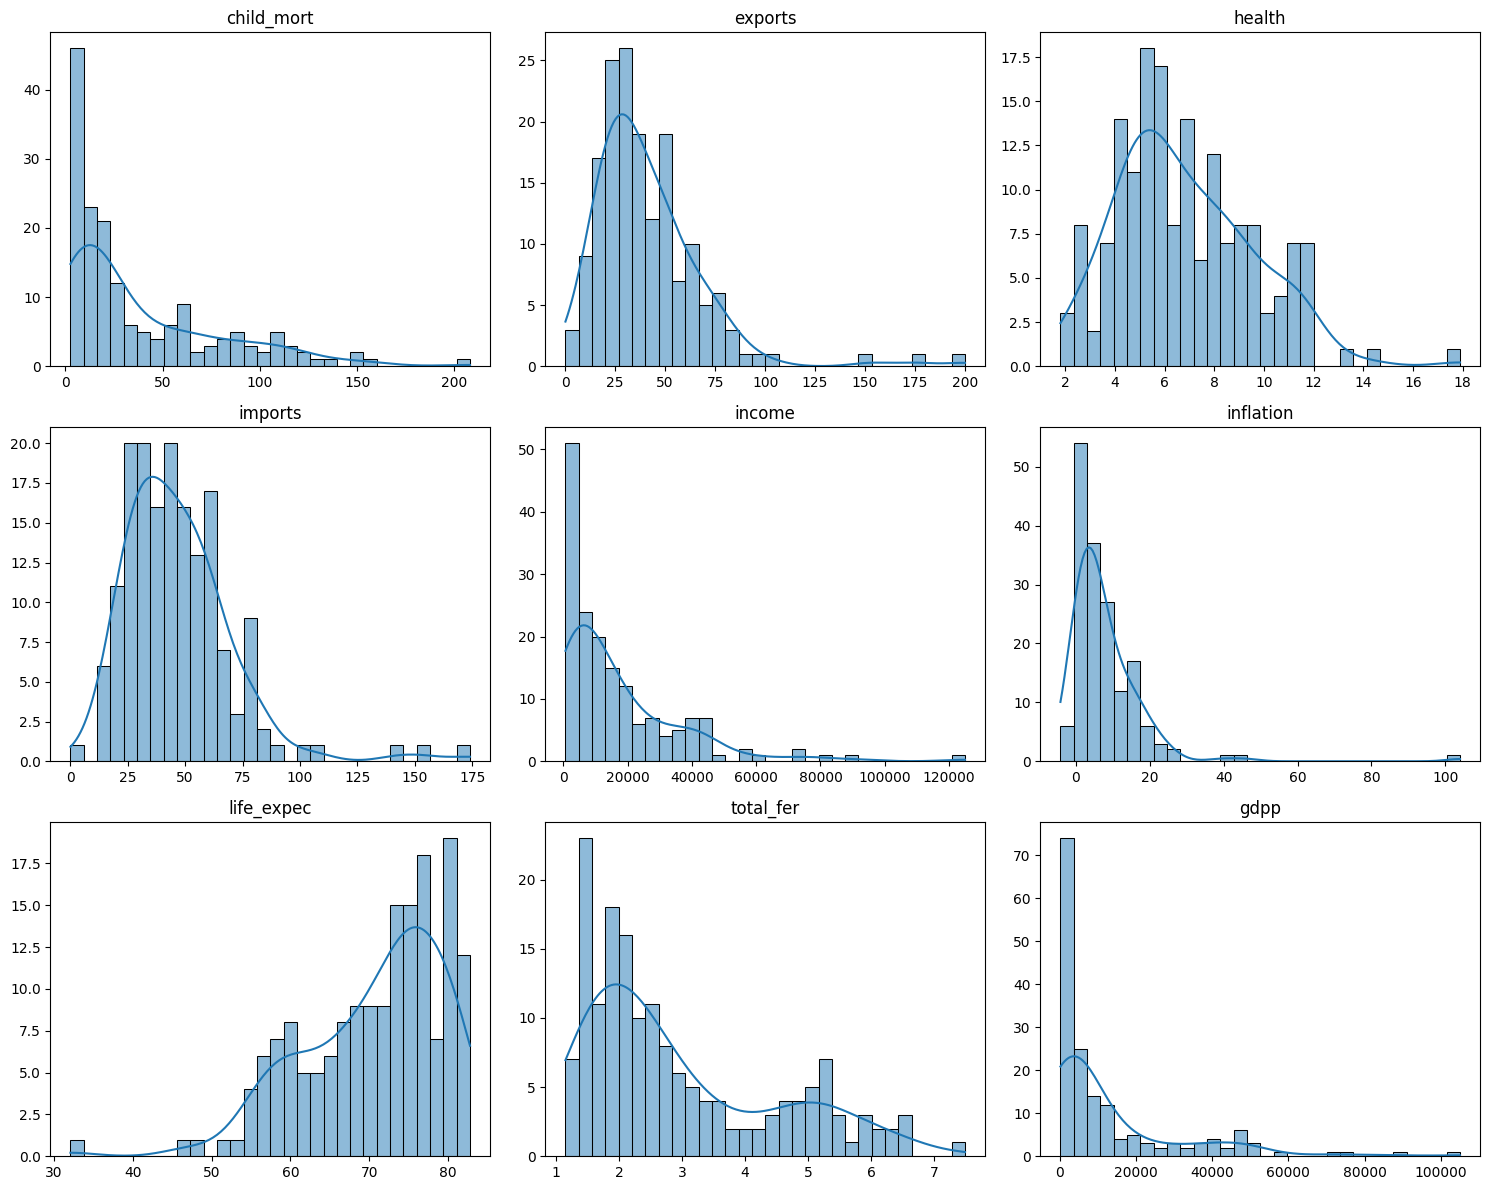

In [55]:
# all histograms

import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include = [np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize = (5 * n_cols, 4 * n_rows ))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

plot_all_histograms(df)


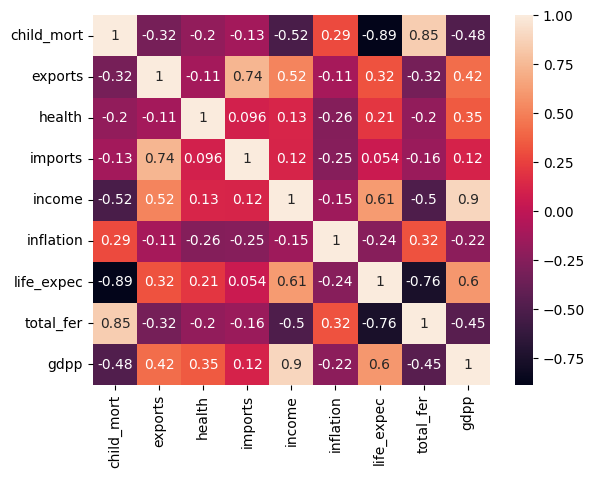

In [56]:
sns.heatmap(df.corr(numeric_only = True), annot = True)
plt.show()


In [57]:
df2 = df.drop("country", axis = 1)
df2


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [58]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()


In [59]:
df2 = scaler.fit_transform(df2)

In [60]:
df2_cols = scaler.get_feature_names_out()

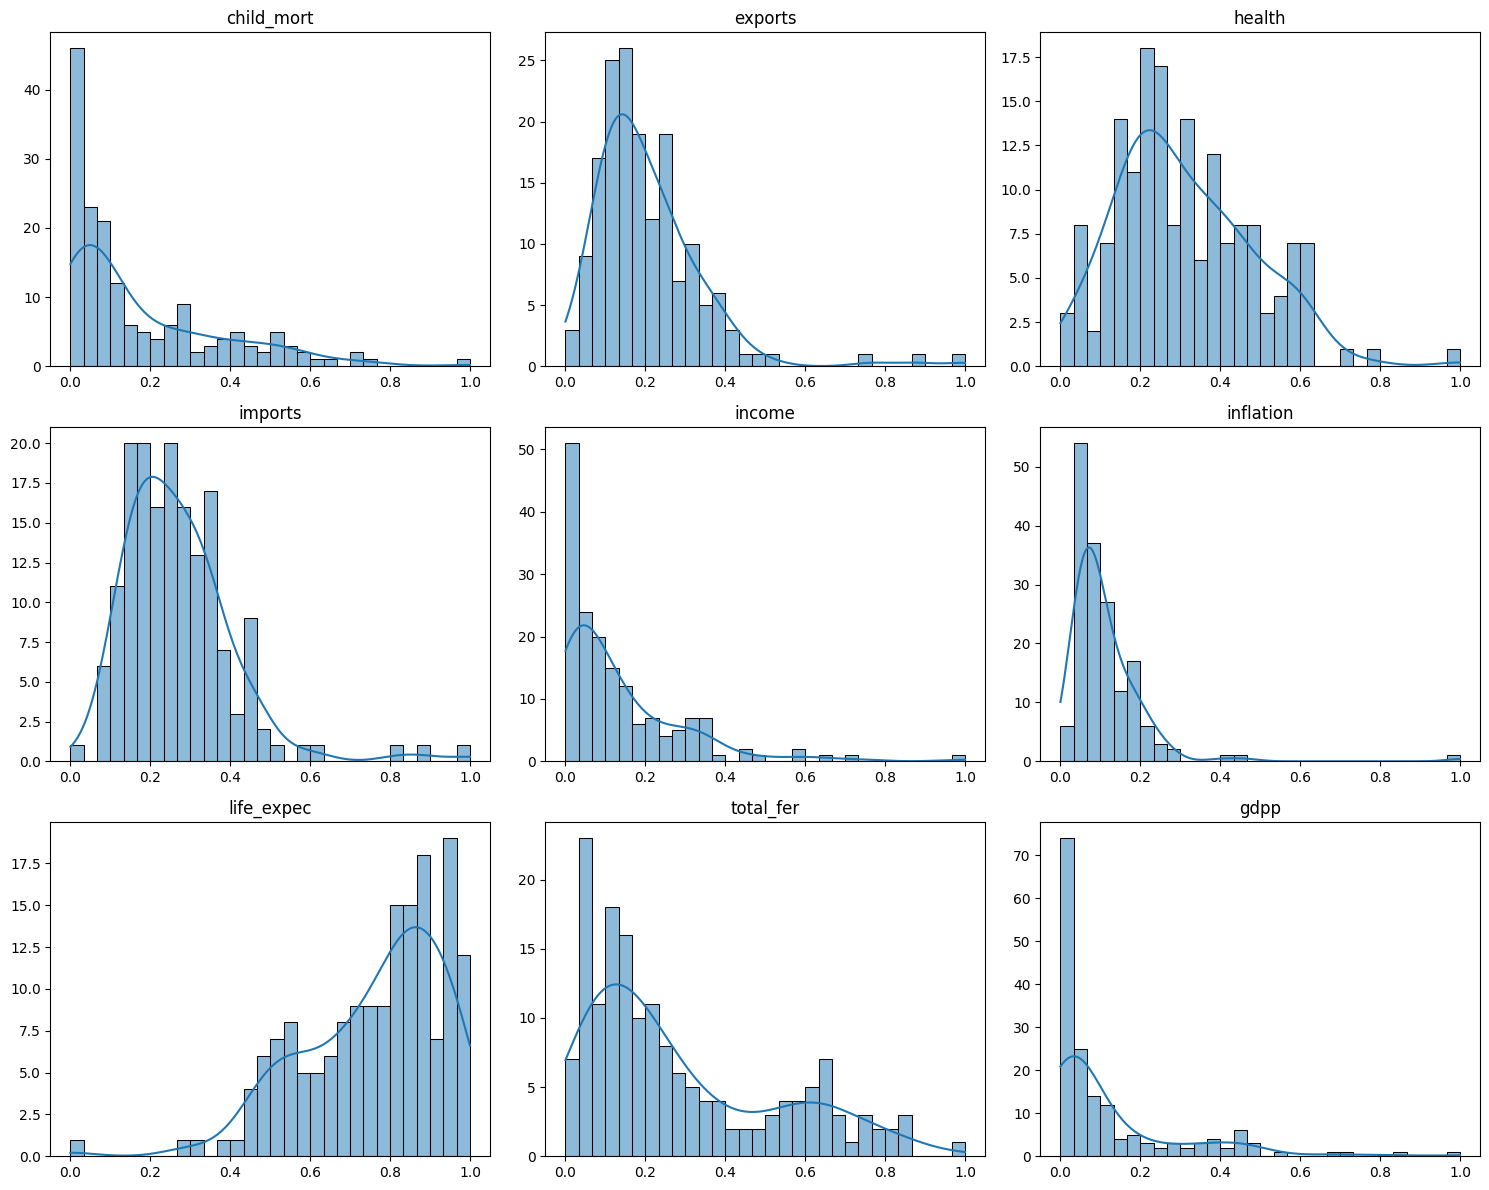

In [61]:
df2 = pd.DataFrame(df2, columns = df2_cols)

df2

plot_all_histograms(df2)


In [62]:
from sklearn.decomposition import PCA
pca = PCA()


In [63]:
pca_df2 = pd.DataFrame(pca.fit_transform(df2))

pca_df2

,0,1,2,3,4,5,6,7,8
0,0.599078,0.095490,0.157554,0.024333,0.045618,-0.046532,-0.076803,-0.040610,0.023572
1,-0.158474,-0.212092,-0.064189,0.061247,-0.014191,-0.010246,0.043567,-0.030842,0.029833
2,-0.003686,-0.135867,-0.134182,-0.133574,0.091150,0.025988,0.045604,0.010198,0.003012
3,0.650235,0.275975,-0.142672,-0.156018,0.081997,0.032170,0.073985,0.045195,-0.042241
4,-0.200711,-0.064662,-0.100715,0.037902,0.035799,-0.055817,0.009559,-0.026228,0.022455
...,...,...,...,...,...,...,...,...,...
162,0.160078,-0.029625,-0.121910,0.066099,0.009043,-0.063646,-0.115254,0.003232,-0.065701
163,-0.061133,-0.171339,-0.058586,-0.247460,0.093260,0.291515,-0.005521,-0.056038,-0.036459
164,-0.115512,-0.032034,-0.195243,0.231993,0.035734,0.089237,0.039743,0.006124,-0.017780
165,0.332968,-0.019824,-0.029989,-0.105416,0.141550,0.063254,-0.012519,-0.014231,-0.011441


In [64]:
pca.explained_variance_

array([0.14180615, 0.03450913, 0.03171502, 0.02513534, 0.00974048,
       0.00776992, 0.00306922, 0.00228894, 0.00178941])

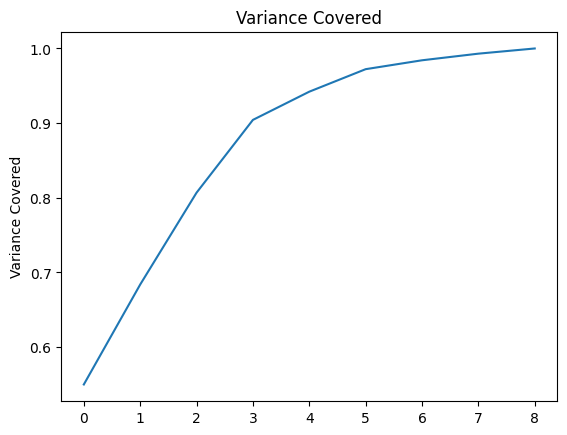

In [65]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.ylabel("Variance Covered")
plt.title("Variance Covered")
plt.show()

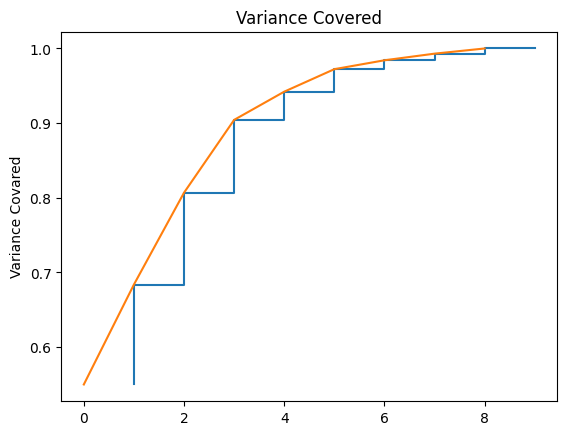

In [66]:
# aslında kümülatif gitmesi yani toplayarak girmesi gerekiyor bunun için plt.step(adım, işlem) np.cumsum ekleriz

plt.step(list(range(1,10)), np.cumsum(pca.explained_variance_ratio_))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.ylabel("Variance Covared")
plt.title("Variance Covered")
plt.show()

In [67]:
# 3 de neredeyse verinin yüzde 90'ını alıyoruz yani pca yi 3 kolon olarak alabiliriz 

pca_df2 = pca_df2.drop(columns = [3,4,5,6,7,8])

pca_df2

,0,1,2
0,0.599078,0.095490,0.157554
1,-0.158474,-0.212092,-0.064189
2,-0.003686,-0.135867,-0.134182
3,0.650235,0.275975,-0.142672
4,-0.200711,-0.064662,-0.100715
...,...,...,...
162,0.160078,-0.029625,-0.121910
163,-0.061133,-0.171339,-0.058586
164,-0.115512,-0.032034,-0.195243
165,0.332968,-0.019824,-0.029989


In [68]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=23)
    kmeans.fit(pca_df2)
    wcss.append(kmeans.inertia_)

wcss


[34.53302925308176,
 17.69539536890408,
 11.270622261541497,
 8.973914858795998,
 7.251844429816183,
 6.565302874945752,
 5.6149366106877485,
 4.79913664258398,
 4.3786090651965415,
 4.096396381535637]

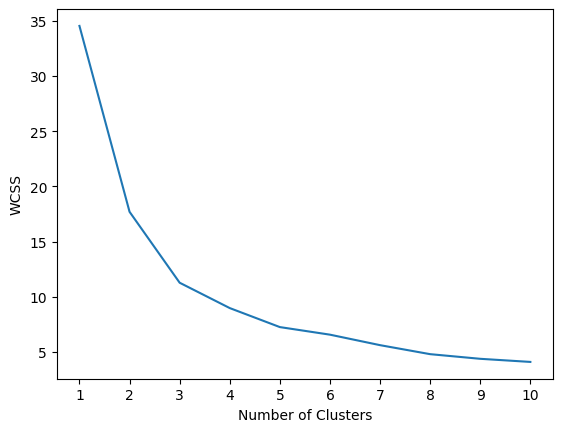

In [69]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


In [70]:
# bu grafik ile çokta anlamlı bir çıkarım elde edemedik 

model = KMeans(n_clusters=3, random_state=23)
model.fit(pca_df2)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",23
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [71]:
labels = model.labels_

In [72]:
silhouette_score(pca_df2, labels)

0.43863203452366817

In [73]:
df["Class"] = labels

In [74]:
df[df["country"] == "Singapore"] # düzeyi kontrol etmek için

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Class
133,Singapore,2.8,200.0,3.96,174.0,72100,-0.046,82.7,1.15,46600,0


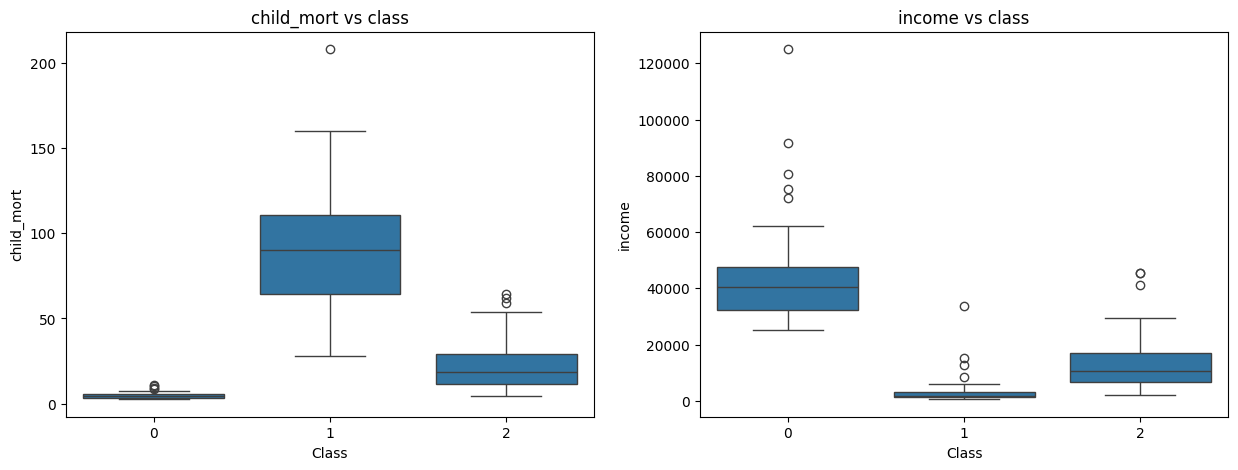

In [75]:
fig, ax = plt.subplots(nrows = 1, ncols= 2 , figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(data=df, x="Class", y="child_mort")
plt.title("child_mort vs class")

plt.subplot(1,2,2)
sns.boxplot(data=df, x="Class", y="income")
plt.title("income vs class")

plt.show()

In [76]:
import plotly.express as px

pca_df2.insert(0, column= "Country", value = df['country'])

pca_df2['Class'] = labels

# Önce sütunun veri tipini değiştiriyoruz

pca_df2["Class"] = pca_df2["Class"].astype("object")

# Sonra atama işlemlerini yapıyoruz

pca_df2.loc[pca_df2["Class"] == 0, "Class"] = "No Budget Needed"
pca_df2.loc[pca_df2["Class"] == 1, "Class"] = "Budget Needed"
pca_df2.loc[pca_df2["Class"] == 2, "Class"] = "In Between"


In [77]:
fig = px.choropleth(
    pca_df2[['Country', 'Class']],
    locationmode = "country names",
    locations = "Country",
    title = "Needed Budget by Country",
    color = pca_df2['Class'],
    color_discrete_map= {
                        "Budget Needed" : "Red",
                        "In Between" : "Yellow",
                        "No Budget Needed": "Green"
    })
fig.update_geos(fitbounds = "locations", visible = True)
fig.show()


In [78]:
# Kümeleme algoritmaları metin verisi kabul etmez, bu yüzden string sütunları atıyoruz
pca_df2 = pca_df2.drop(columns=["Country", "Class"])

model = KMeans(n_clusters=3, random_state=23)
model.fit(pca_df2)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",23
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [79]:
labels = model.labels_

In [80]:
print("Kmeans SS with PCA",silhouette_score(pca_df2, labels))

Kmeans SS with PCA 0.43863203452366817


In [81]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=3)

y_hc = hc.fit_predict(pca_df2)

print(f"HC SS with PCA: {silhouette_score(pca_df2, y_hc)}")


HC SS with PCA: 0.3982696676459872


In [82]:
from sklearn.cluster import DBSCAN, HDBSCAN

db = DBSCAN()

db.fit(pca_df2)

dblabel = db.labels_

print("DB SS with PCA", silhouette_score(pca_df2, dblabel))


DB SS with PCA 0.5991957878323004


In [83]:
hdb = HDBSCAN()

hdb.fit(pca_df2)

hdblabel = hdb.labels_

print("HDB SS PCA",silhouette_score(pca_df2, hdblabel))


HDB SS PCA 0.19354663587118467


In [84]:
# HYPERPARAMETER TUNING

eps_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [4, 5, 6]

results = []

for eps in eps_values:
    for min_samples_val in min_samples_values:

        db = DBSCAN(eps=eps, min_samples=min_samples_val).fit(pca_df2)

        labels = db.labels_

        if len(set(labels)) <= 1:
            continue

        silhouette = silhouette_score(pca_df2, labels)
        results.append(
            {
                "eps" : eps,
                "min_samples" : min_samples_val,
                "Silhouette" : silhouette,
                "n_clusters" : len(set(labels)) - (1 if -1 in labels else 0)
            }
        )

results_df = pd.DataFrame(results).sort_values(by="Silhouette", ascending=False)

results_df


,eps,min_samples,Silhouette,n_clusters
15,0.6,4,0.602042,1
17,0.6,6,0.602042,1
16,0.6,5,0.602042,1
11,0.4,6,0.599196,1
14,0.5,6,0.599196,1
9,0.4,4,0.599196,1
10,0.4,5,0.599196,1
13,0.5,5,0.599196,1
12,0.5,4,0.599196,1
7,0.3,5,0.503040,1


In [85]:
from sklearn.cluster import HDBSCAN

min_cluster_sizes = [3, 5, 7, 10]
min_samples_list = [None, 3, 5, 7] 

results_hdbscan = []

for min_cluster in min_cluster_sizes:
    for min_sample in min_samples_list:
       
        hdb = HDBSCAN(min_cluster_size=min_cluster, min_samples=min_sample).fit(pca_df2)

        labels = hdb.labels_

        if len(set(labels)) <= 1:
            continue

        silhouette = silhouette_score(pca_df2, labels)
        results_hdbscan.append(
            {
                "min_cluster" : min_cluster, 
                "min_sample" : min_sample,
                "Silhouette" : silhouette,
                "n_clusters" : len(set(labels)) - (1 if -1 in labels else 0)
            }
        )

results_hdbscan_df = pd.DataFrame(results_hdbscan).sort_values(by="Silhouette", ascending=False)

results_hdbscan_df


,min_cluster,min_sample,Silhouette,n_clusters
13,10,3.0,0.240060,3
6,5,5.0,0.193547,3
10,7,5.0,0.193547,3
4,5,NaN,0.193547,3
14,10,5.0,0.193547,3
2,3,5.0,0.186452,4
9,7,3.0,0.184889,5
5,5,3.0,0.184889,5
11,7,7.0,0.155991,3
8,7,NaN,0.155991,3


In [86]:
# CLUSTERING WITHOUT PCA

df = df.drop(["country", "Class"], axis = 1)

In [87]:
df

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [88]:
scaler = MinMaxScaler()

df = scaler.fit_transform(df)

df_cols = scaler.get_feature_names_out()


In [89]:
df = pd.DataFrame(df, columns = df_cols)
df


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,0.426485,0.049482,0.358608,0.257765,0.008047,0.126144,0.475345,0.736593,0.003073
1,0.068160,0.139531,0.294593,0.279037,0.074933,0.080399,0.871795,0.078864,0.036833
2,0.120253,0.191559,0.146675,0.180149,0.098809,0.187691,0.875740,0.274448,0.040365
3,0.566699,0.311125,0.064636,0.246266,0.042535,0.245911,0.552268,0.790221,0.031488
4,0.037488,0.227079,0.262275,0.338255,0.148652,0.052213,0.881657,0.154574,0.114242
...,...,...,...,...,...,...,...,...,...
162,0.129503,0.232582,0.213797,0.302609,0.018820,0.063118,0.609467,0.370662,0.026143
163,0.070594,0.142032,0.192666,0.100809,0.127750,0.463081,0.854043,0.208202,0.126650
164,0.100779,0.359651,0.312617,0.460715,0.031200,0.150725,0.808679,0.126183,0.010299
165,0.261441,0.149536,0.209447,0.197397,0.031120,0.257000,0.698225,0.555205,0.010299


In [90]:
df_wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=23)
    kmeans.fit(df)
    df_wcss.append(kmeans.inertia_)

df_wcss


[42.798718775687526,
 25.943231842142815,
 19.35198252576052,
 16.980125970358465,
 15.130351332188344,
 14.075812012597803,
 12.939884936985328,
 11.78106339126313,
 10.819809884973218,
 10.18768946547927]

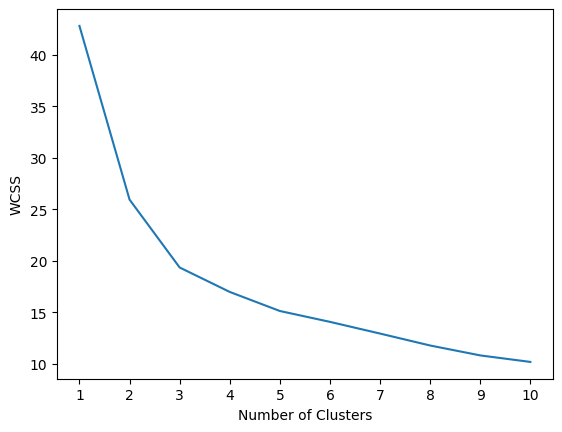

In [91]:
plt.plot(range(1,11), df_wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


In [92]:
from kneed import KneeLocator

kl = KneeLocator(range(1,11), df_wcss, curve="convex", direction="decreasing")

kl.elbow

np.int64(3)

In [93]:
model = KMeans(n_clusters=3, random_state=23)
model.fit(df)

labels = model.labels_

print("Kmeans Silhouette Score: ",silhouette_score(df, labels))


Kmeans Silhouette Score:  0.33976487765323604


In [94]:
hc = AgglomerativeClustering(n_clusters=3)

y_hc = hc.fit_predict(df)

print(f"HC Silhouette Score: {silhouette_score(df, y_hc)}")


HC Silhouette Score: 0.31627506051649634


In [95]:
from sklearn.cluster import DBSCAN, HDBSCAN

db = DBSCAN()

db.fit(df)

dblabel = db.labels_

print("DB Silhouette Score: ", silhouette_score(df, dblabel))


DB Silhouette Score:  0.4993958842751086


In [96]:
hdb = HDBSCAN()

hdb.fit(df)

hdblabel = hdb.labels_

print("HDB Silhouette Score: ",silhouette_score(df, hdblabel))


HDB Silhouette Score:  0.12498503688620508


In [97]:
# HYPERPARAMETER TUNING

eps_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [4, 5, 6]

results = []

for eps in eps_values:
    for min_samples_val in min_samples_values:

        db = DBSCAN(eps=eps, min_samples=min_samples_val).fit(df)

        labels = db.labels_

        if len(set(labels)) <= 1:
            continue

        silhouette = silhouette_score(df, labels)
        results.append(
            {
                "eps" : eps,
                "min_samples" : min_samples_val,
                "Silhouette" : silhouette,
                "n_clusters" : len(set(labels)) - (1 if -1 in labels else 0)
            }
        )

results_df = pd.DataFrame(results).sort_values(by="Silhouette", ascending=False)

results_df


,eps,min_samples,Silhouette,n_clusters
15,0.6,6,0.526549,1
13,0.6,4,0.526549,1
14,0.6,5,0.526549,1
11,0.5,5,0.499396,1
12,0.5,6,0.499396,1
10,0.5,4,0.499396,1
7,0.4,4,0.482049,1
8,0.4,5,0.482049,1
9,0.4,6,0.482049,1
4,0.3,4,0.360426,1


In [98]:
from sklearn.cluster import HDBSCAN

min_cluster_sizes = [3, 5, 7, 10]
min_samples_list = [None, 3, 5, 7] 

results_hdbscan = []

for min_cluster in min_cluster_sizes:
    for min_sample in min_samples_list:
    
        hdb = HDBSCAN(min_cluster_size=min_cluster, min_samples=min_sample).fit(df)

        labels = hdb.labels_

        if len(set(labels)) <= 1:
            continue

        silhouette = silhouette_score(df, labels)
        results_hdbscan.append(
            {
                "min_cluster" : min_cluster, 
                "min_sample" : min_sample,
                "Silhouette" : silhouette,
                "n_clusters" : len(set(labels)) - (1 if -1 in labels else 0)
            }
        )

results_hdbscan_df = pd.DataFrame(results_hdbscan).sort_values(by="Silhouette", ascending=False)

results_hdbscan_df

,min_cluster,min_sample,Silhouette,n_clusters
13,10,3.0,0.162454,3
9,7,3.0,0.162454,3
2,3,5.0,0.124985,3
4,5,NaN,0.124985,3
10,7,5.0,0.124985,3
14,10,5.0,0.124985,3
6,5,5.0,0.124985,3
3,3,7.0,0.082511,3
11,7,7.0,0.082511,3
8,7,NaN,0.082511,3
